<a href="https://colab.research.google.com/github/randabsk1-maker/mon-projet-colab/blob/main/TP_R_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installer R et le connecteur Python ↔ R
!apt-get update -qq
!apt-get install -y r-base
!pip install -q rpy2

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.2-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 118 not upgraded.


In [ ]:
# Activer les cellules R dans Jupyter / Colab
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R

# ==============================
# TP XGBoost RAPIDE CORRIGÉ
#

install.packages("mlbench", repos="https://cloud.r-project.org")
install.packages("xgboost", repos="https://cloud.r-project.org")
install.packages("pROC", repos="https://cloud.r-project.org")

library(mlbench)
library(xgboost)
library(pROC)

cat("Packages chargés\n")

# ==============================
# Charger dataset
# ==============================

data(BreastCancer)
df <- BreastCancer

# enlever ID
df$Id <- NULL

# supprimer NA
df <- na.omit(df)

# cible AVANT conversion
y <- ifelse(df$Class == "malignant", 1, 0)

# enlever la colonne cible
df$Class <- NULL

# convertir les variables en numérique
df[] <- lapply(df, function(x) as.numeric(as.character(x)))

X <- as.matrix(df)

cat("Dataset :", nrow(X), "échantillons\n")

# ==============================
# Train / Test
# ==============================

set.seed(42)

train_idx <- sample(1:nrow(X), 0.75*nrow(X))

X_train <- X[train_idx,]
y_train <- y[train_idx]

X_test <- X[-train_idx,]
y_test <- y[-train_idx]

# ==============================
# XGBoost
# ==============================

dtrain <- xgb.DMatrix(data = X_train, label = y_train)
dtest  <- xgb.DMatrix(data = X_test, label = y_test)

params <- list(
  objective = "binary:logistic",
  eval_metric = "auc",
  max_depth = 3,
  eta = 0.1
)

model <- xgb.train(
  params = params,
  data = dtrain,
  nrounds = 40,
  verbose = 0
)

cat("Modèle entraîné\n")

# ==============================
# Prédiction
# ==============================

pred_prob <- predict(model, dtest)

pred <- ifelse(pred_prob > 0.5, 1, 0)

accuracy <- mean(pred == y_test)

cat("Accuracy :", accuracy, "\n")

auc <- roc(y_test, pred_prob)$auc

cat("AUC :", auc, "\n")

cat("TP terminé\n")

Packages chargés
Dataset : 683 échantillons
Modèle entraîné
Accuracy : 0.9532164 
AUC : 0.9888889 
TP terminé


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/mlbench_2.1-7.tar.gz'
Content type 'application/x-gzip' length 991847 bytes (968 KB)
downloaded 968 KB


The downloaded source packages are in
	‘/tmp/RtmpHbuiai/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/xgboost_3.2.0.1.tar.gz'
Content type 'application/x-gzip' length 1624855 bytes (1.5 MB)
downloaded 1.5 MB


The downloaded source packages are in
	‘/tmp/RtmpHbuiai/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/pROC_1.19.0.1.tar.gz'
Content type 'application/x-gzip' length 449573 bytes (439 KB)
downloaded 439 KB


The downloaded source packages are in
	‘/tmp/RtmpHbuiai/downloaded_packages’
Type 'citation("pROC")' for a citation.

Attachin

In [ ]:
!pip install rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
print("R fonctionne")

[1] "R fonctionne"


AUC : 0.9888889 
           Feature        Gain      Cover  Frequency
            <char>       <num>      <num>      <num>
1:      Cell.shape 0.741459998 0.33505221 0.12206573
2:     Bare.nuclei 0.104396304 0.27011970 0.24882629
3:       Cell.size 0.065850438 0.17611883 0.14084507
4:    Cl.thickness 0.034768812 0.09394695 0.21126761
5:    Epith.c.size 0.023036148 0.01173015 0.02816901
6:     Bl.cromatin 0.018481922 0.03424343 0.07042254
7: Normal.nucleoli 0.007183187 0.02456244 0.07042254
8:   Marg.adhesion 0.004823192 0.05422628 0.10798122


Setting levels: control = 0, case = 1
Setting direction: controls < cases


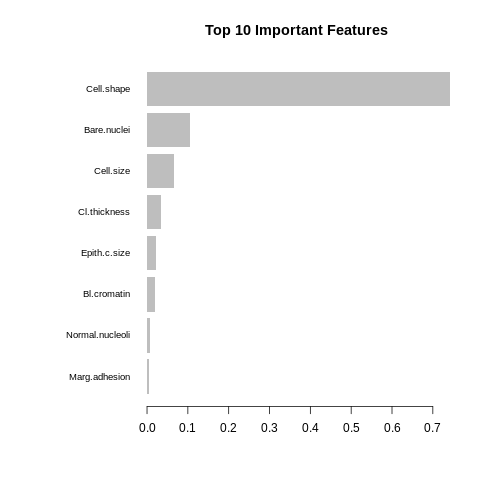

In [ ]:
%%R

library(pROC)
library(xgboost)

# ==============================
# Courbe ROC
# ==============================

roc_obj <- roc(y_test, pred_prob)

plot(
  roc_obj,
  col="blue",
  lwd=2,
  main="ROC Curve - XGBoost Model"
)

cat("AUC :", auc(roc_obj), "\n")

# ==============================
# Importance des variables
# ==============================

importance <- xgb.importance(model = model)

print(importance)

xgb.plot.importance(
  importance_matrix = importance,
  top_n = 10,
  main = "Top 10 Important Features"
)